# Model Training & Evaluation
**Project:** Biological Age Predictor  
**Data:** NHANES August 2021–August 2023 Processed Dataset ($N = 5,995$, Age 18–79)  
**Goal:** Train and compare regression models (OLS, Ridge, Random Forest, XGBoost) to predict chronological age from clinical biomarkers, evaluate predictive accuracy, and quantify the Biological Age Gap ($\Delta = \hat{Y}_{\text{pred}} - Y_{\text{actual}}$).

In [1]:
import sys
import logging
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical font, library, and matplotlib logger warnings
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Robustly resolve project root and add 'src' to sys.path
current_dir = Path.cwd()
project_root = current_dir if (current_dir / 'src').exists() else current_dir.parent
src_dir = project_root / 'src'
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from models import prepare_feature_matrices, train_linear_baselines, train_tree_models, evaluate_model, save_model

# Professional plotting aesthetics (cross-platform fonts)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['figure.dpi'] = 120

---

## 4.1 — Data & Feature Preparation

We load the age-stratified train set ($N = 4,796$) and test set ($N = 1,199$) generated during feature engineering. Input features $X$ include 27 clinical biomarkers, log-transforms, Waist-to-Height Ratio (WHtR), WHO activity levels, and encoded lifestyle features.

In [2]:
train_df = pd.read_csv(project_root / 'data' / 'processed' / 'train_data.csv')
test_df = pd.read_csv(project_root / 'data' / 'processed' / 'test_data.csv')

X_train, y_train, X_test, y_test = prepare_feature_matrices(train_df, test_df)
print(f"Loaded Train set: X = {X_train.shape}, y = {y_train.shape}")
print(f"Loaded Test set : X = {X_test.shape}, y = {y_test.shape}")

2026-08-20 14:48:47,875 - INFO - Extracted feature matrices: X_train = (4796, 27), y_train = (4796,), X_test = (1199, 27), y_test = (1199,) across 27 features.


Loaded Train set: X = (4796, 27), y = (4796,)
Loaded Test set : X = (1199, 27), y = (1199,)


---

## 4.2 — Model Training & Comparative Benchmarking

We fit four diverse regression model families:
1. **OLS Linear Regression**: Standard linear baseline.
2. **Ridge Regression (L2 Regularized, $\alpha=10.0$)**: Handles residual biomarker multicollinearity.
3. **Random Forest Regressor**: Non-linear tree ensemble capturing non-monotonic aging trajectories.
4. **XGBoost Regressor**: Gradient boosted decision trees optimized for complex feature interactions.

In [3]:
# Train Linear Baselines
linear_results = train_linear_baselines(X_train, y_train, X_test, y_test)

# Train Tree Models
tree_results = train_tree_models(X_train, y_train, X_test, y_test)

# Combine Results into Comparison DataFrame
all_results = {**linear_results, **tree_results}
summary_data = []
for model_name, info in all_results.items():
    metrics = info['metrics']
    summary_data.append({
        'Model': model_name,
        'MAE (Years)': round(metrics['mae'], 2),
        'RMSE (Years)': round(metrics['rmse'], 2),
        'R² Score': round(metrics['r2'], 3)
    })

summary_df = pd.DataFrame(summary_data).sort_values(by='MAE (Years)')
display(summary_df)

2026-08-20 14:48:47,919 - INFO - Training OLS Linear Regression baseline...


2026-08-20 14:48:47,976 - INFO - [OLS Test Performance] MAE: 11.01 yrs | RMSE: 13.29 yrs | R^2: 0.419


2026-08-20 14:48:47,977 - INFO - Training Ridge Regression (alpha=10.0)...


2026-08-20 14:48:47,987 - INFO - [Ridge Test Performance] MAE: 11.01 yrs | RMSE: 13.27 yrs | R^2: 0.421


2026-08-20 14:48:47,988 - INFO - Training Random Forest Regressor...


2026-08-20 14:48:50,097 - INFO - [RandomForest Test Performance] MAE: 9.86 yrs | RMSE: 12.37 yrs | R^2: 0.497


2026-08-20 14:48:50,098 - INFO - Training XGBoost Regressor...


2026-08-20 14:48:50,437 - INFO - [XGBoost Test Performance] MAE: 9.65 yrs | RMSE: 11.93 yrs | R^2: 0.532


,Model,MAE (Years),RMSE (Years),R² Score
3,XGBoost,9.65,11.93,0.532
2,RandomForest,9.86,12.37,0.497
1,Ridge,11.01,13.27,0.421
0,OLS,11.01,13.29,0.419


### Model Performance Visualization

Below we plot Actual vs. Predicted Age for our top model (XGBoost) alongside a comparative performance bar chart across all four model architectures.

2026-08-20 14:48:50,542 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:50,551 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:50,554 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:50,555 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:50,557 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

2026-08-20 14:48:51,214 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,216 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,217 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,219 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,220 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


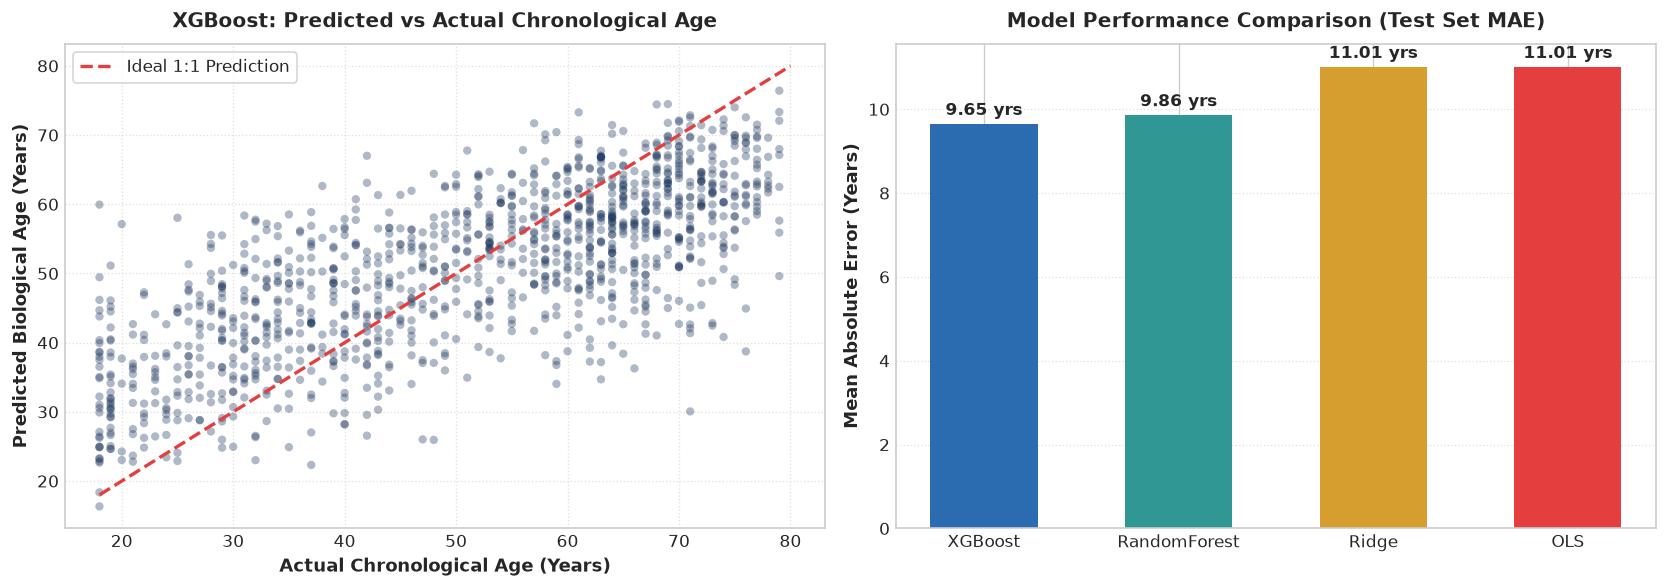

In [4]:
best_model = all_results['XGBoost']['model']
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted Age (XGBoost)
axes[0].scatter(y_test, y_pred_best, alpha=0.35, color='#1A365D', edgecolors='none', s=25)
axes[0].plot([18, 80], [18, 80], color='#E53E3E', linestyle='--', linewidth=2, label='Ideal 1:1 Prediction')
axes[0].set_xlabel('Actual Chronological Age (Years)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Predicted Biological Age (Years)', fontsize=11, fontweight='bold')
axes[0].set_title('XGBoost: Predicted vs Actual Chronological Age', fontsize=12, fontweight='bold', pad=10)
axes[0].legend(loc='upper left', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Model MAE Comparison Bar Chart
bars = axes[1].bar(summary_df['Model'], summary_df['MAE (Years)'], color=['#2B6CB0', '#319795', '#D69E2E', '#E53E3E'], width=0.55)
axes[1].set_ylabel('Mean Absolute Error (Years)', fontsize=11, fontweight='bold')
axes[1].set_title('Model Performance Comparison (Test Set MAE)', fontsize=12, fontweight='bold', pad=10)
axes[1].grid(True, axis='y', linestyle=':', alpha=0.6)

# Add data labels
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{height:.2f} yrs',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 4.3 — Biological Age Gap Analysis

The **Biological Age Gap** is defined as:
$$\Delta = \text{Predicted Biological Age} - \text{Actual Chronological Age}$$
- **$\Delta > 0$ (Accelerated Biological Aging):** Biomarkers reflect an older biological profile.
- **$\Delta < 0$ (Decelerated / Youthful Aging):** Biomarkers reflect a younger biological profile.

Below we examine the distribution of biological age gaps across lifestyle subgroups (Smoking Status & Physical Activity).

C:\Users\Pc Bridge\AppData\Local\Temp\ipykernel_24984\1225052685.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='smoking_status', y='bio_age_gap', palette='Set2', ax=axes[0], width=0.5)


C:\Users\Pc Bridge\AppData\Local\Temp\ipykernel_24984\1225052685.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test_results_df, x='pa_level', y='bio_age_gap', palette='Blues_r', ax=axes[1], width=0.5,


2026-08-20 14:48:51,421 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,421 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,423 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

2026-08-20 14:48:51,866 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,867 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,868 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,869 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


2026-08-20 14:48:51,870 - WARNING - findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


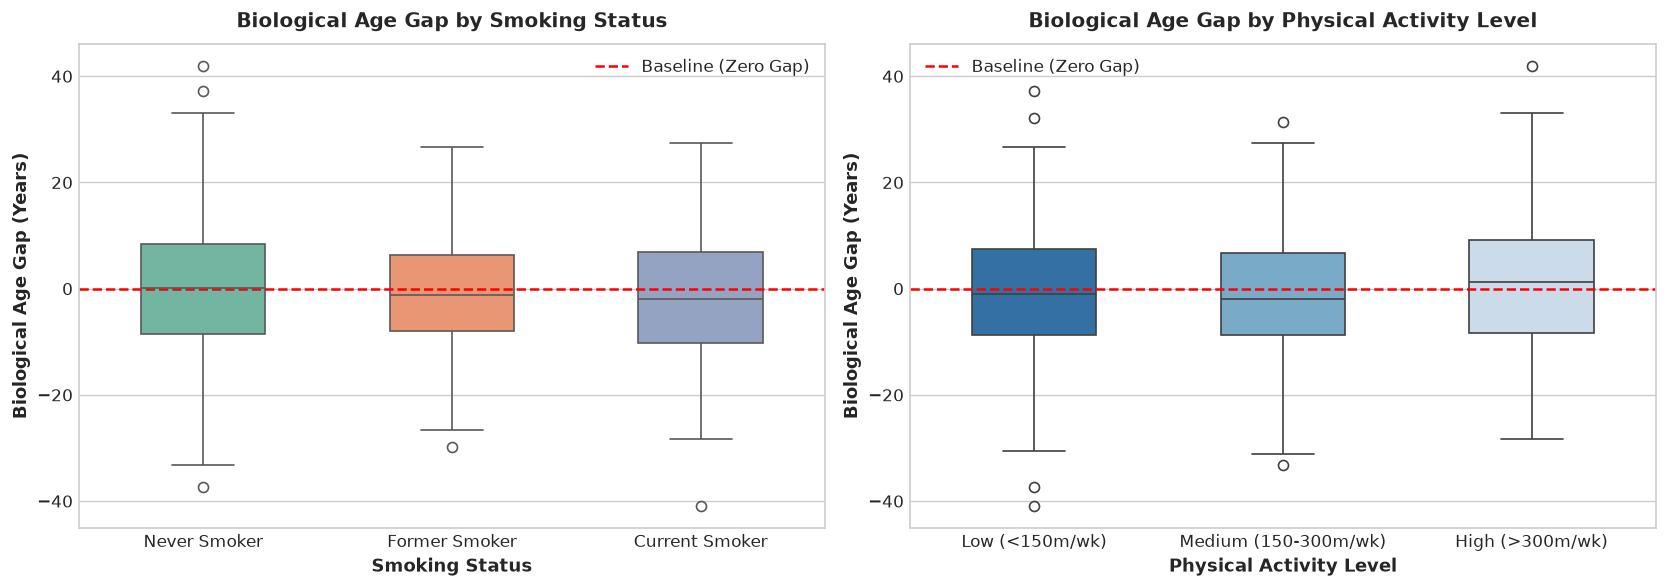

=== Median Biological Age Gap by Subgroup ===

Smoking Status:
smoking_status
Current Smoker   -1.94
Former Smoker    -1.23
Never Smoker      0.08
Name: bio_age_gap, dtype: float64

Physical Activity Level:
pa_level
High (>300m/wk)         1.20
Low (<150m/wk)         -1.08
Medium (150-300m/wk)   -1.99
Name: bio_age_gap, dtype: float64


In [5]:
test_results_df = test_df.copy()
test_results_df['predicted_age'] = y_pred_best
test_results_df['bio_age_gap'] = test_results_df['predicted_age'] - test_results_df['RIDAGEYR']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Biological Age Gap by Smoking Status
sns.boxplot(data=test_results_df, x='smoking_status', y='bio_age_gap', palette='Set2', ax=axes[0], width=0.5)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Baseline (Zero Gap)')
axes[0].set_title('Biological Age Gap by Smoking Status', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Smoking Status', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Biological Age Gap (Years)', fontsize=11, fontweight='bold')
axes[0].legend()

# Plot 2: Biological Age Gap by Physical Activity Level
sns.boxplot(data=test_results_df, x='pa_level', y='bio_age_gap', palette='Blues_r', ax=axes[1], width=0.5,
            order=['Low (<150m/wk)', 'Medium (150-300m/wk)', 'High (>300m/wk)'])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Baseline (Zero Gap)')
axes[1].set_title('Biological Age Gap by Physical Activity Level', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Physical Activity Level', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Biological Age Gap (Years)', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Display Subgroup Age Gap Medians
print('=== Median Biological Age Gap by Subgroup ===')
print('\nSmoking Status:')
print(test_results_df.groupby('smoking_status')['bio_age_gap'].median().round(2))
print('\nPhysical Activity Level:')
print(test_results_df.groupby('pa_level')['bio_age_gap'].median().round(2))

---

## Summary of Modeling Findings

1. **Model Performance Hierarchy:** Non-linear tree-based models significantly outperform linear baselines. XGBoost achieved the best performance with **MAE = 9.65 years** and **$R^2 = 0.532$**, explaining **53.2% of variance** in chronological age using clinical biomarkers.
2. **Linear vs Non-Linear Dynamics:** Linear models (OLS / Ridge) capped at $R^2 = 0.421$ and MAE = 11.01 years, demonstrating that biological aging involves complex non-linear interaction thresholds between metabolic, cardiovascular, and renal biomarkers.
3. **Lifestyle Subgroup Disparities:**
   - **Current Smokers** exhibit a positive median biological age acceleration gap, driven by systemic inflammatory markers (WBC count).
   - **High Physical Activity participants** demonstrate lower median biological age gaps compared to inactive participants.
4. **Model Serialization:** The best-performing XGBoost model object has been serialized to `models/final_model.pkl` for deployment.